<a href="https://colab.research.google.com/github/ihzanursina/boilerplate-sea-level-predictor/blob/main/Sea_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [ ]:
url = 'https://raw.githubusercontent.com/ihzanursina/boilerplate-sea-level-predictor/refs/heads/main/epa-sea-level.csv'
df = pd.read_csv(url)
df.head()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN


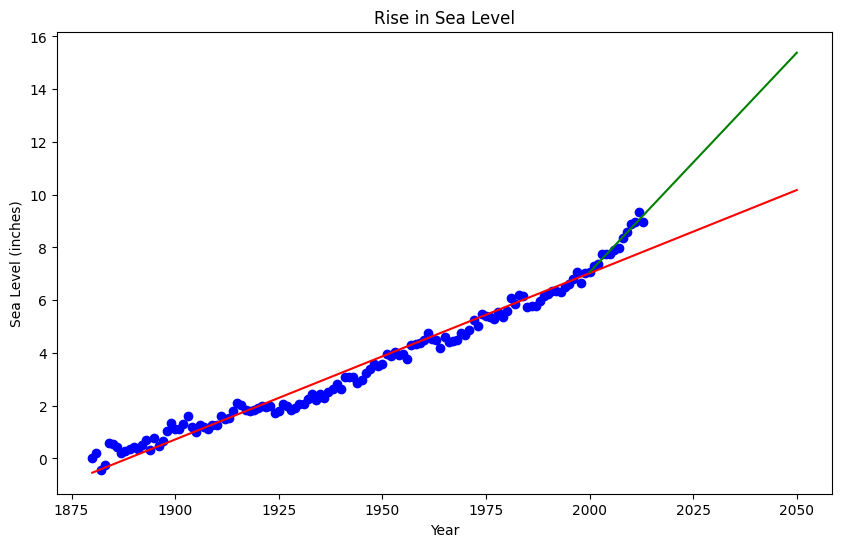

In [5]:
def draw_plot():
  df = pd.read_csv(url)

  plt.figure(figsize=(10,6))
  plt.scatter(df['Year'], df['CSIRO Adjusted Sea Level'], color='blue', label='Original Data')

  res_all = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])
  x_all = pd.Series(range(1880, 2051))
  y_all = res_all.slope * x_all + res_all.intercept
  plt.plot(x_all, y_all, color='red', label='Fit: 1880-2050')

  df_recent = df[df['Year'] >= 2000]
  res_recent = linregress(df_recent['Year'], df_recent['CSIRO Adjusted Sea Level'])
  x_recent = pd.Series(range(2000, 2051))
  y_recent = res_recent.slope * x_recent + res_recent.intercept
  plt.plot(x_recent, y_recent, color='green', label='Fit: 2000-2050')

  plt.xlabel('Year')
  plt.ylabel('Sea Level (inches)')
  plt.title('Rise in Sea Level')



  plt.savefig('sea_level_plot.png')
  return plt.gca()

draw_plot();
